<a href="https://colab.research.google.com/github/lucastelesx/magicSplitCrop/blob/testing/magicSplitCropTests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic usage example

## Checking Torch

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

## Install SAM + model

In [ ]:
!git clone https://github.com/facebookresearch/sam2.git
%cd /content/sam2
!pip install matplotlib pillow opencv-python
!mkdir -p checkpoints
!wget -P checkpoints https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt

## Upload image file

In [ ]:
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "2026-grouped-flash-25.jpg"

image_pil = Image.open(image_path).convert("RGB")
image = np.array(image_pil)

print(image.shape)

(2144, 1206, 3)


In [ ]:
plt.figure(figsize=(3, 9))
plt.imshow(image)
plt.axis("off")
plt.show()

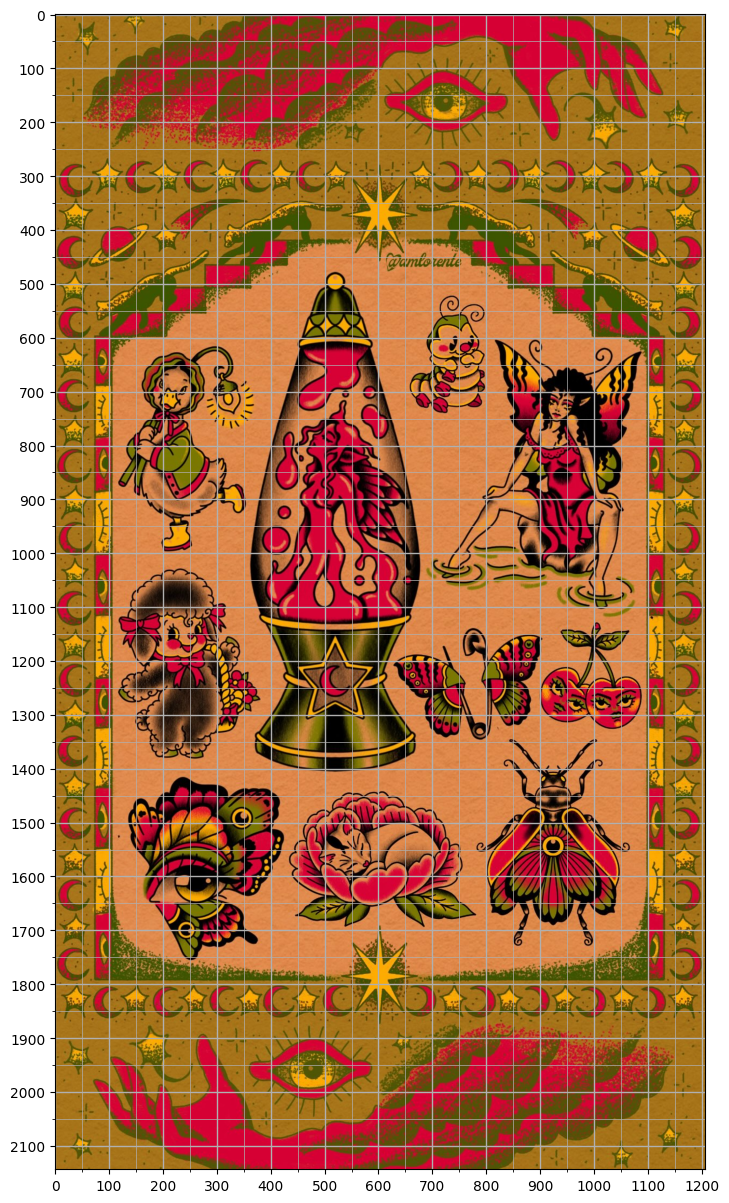

In [ ]:

#import torch???necessary????

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

checkpoint = "checkpoints/sam2_hiera_small.pt"
model_cfg = "sam2_hiera_s.yaml"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam2_model = build_sam2(
    model_cfg,
    checkpoint,
    device=device
)

predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(image)

input_point = np.array

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 15))

ax.imshow(image)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))

ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

ax.grid(which="major", linewidth=1)
ax.grid(which="minor", linewidth=0.5)

plt.show()

## Point in and out + score result

In [ ]:
input_point = np.array([
    [545, 900],
    [785, 850]
])

input_label = np.array([
    1,
    0
])

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

print("Quantidade de máscaras:", len(masks))
print("Scores:", scores)

best_index = np.argmax(scores)

best_mask = masks[best_index]

print(best_mask.shape)

Quantidade de máscaras: 3
Scores: [0.00214321 0.02447828 0.12738271]
(2144, 1206)


## Preview gray scale

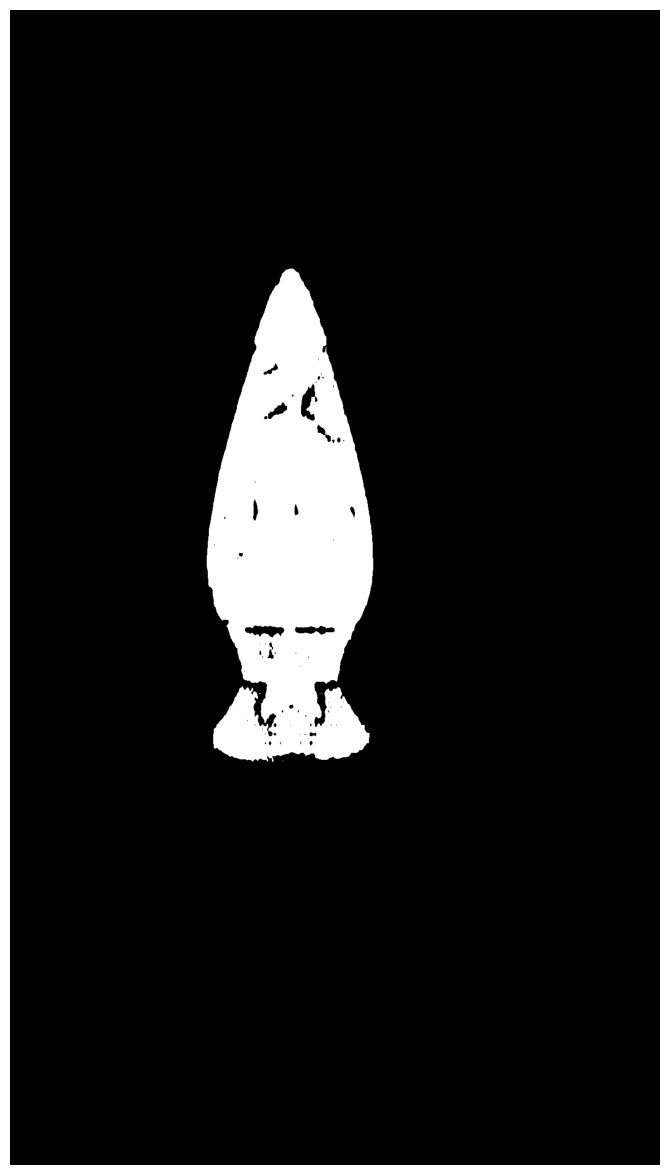

In [ ]:
plt.figure(figsize=(10, 15))
plt.imshow(best_mask, cmap="gray")
plt.axis("off")
plt.show()

## Preview mask+image

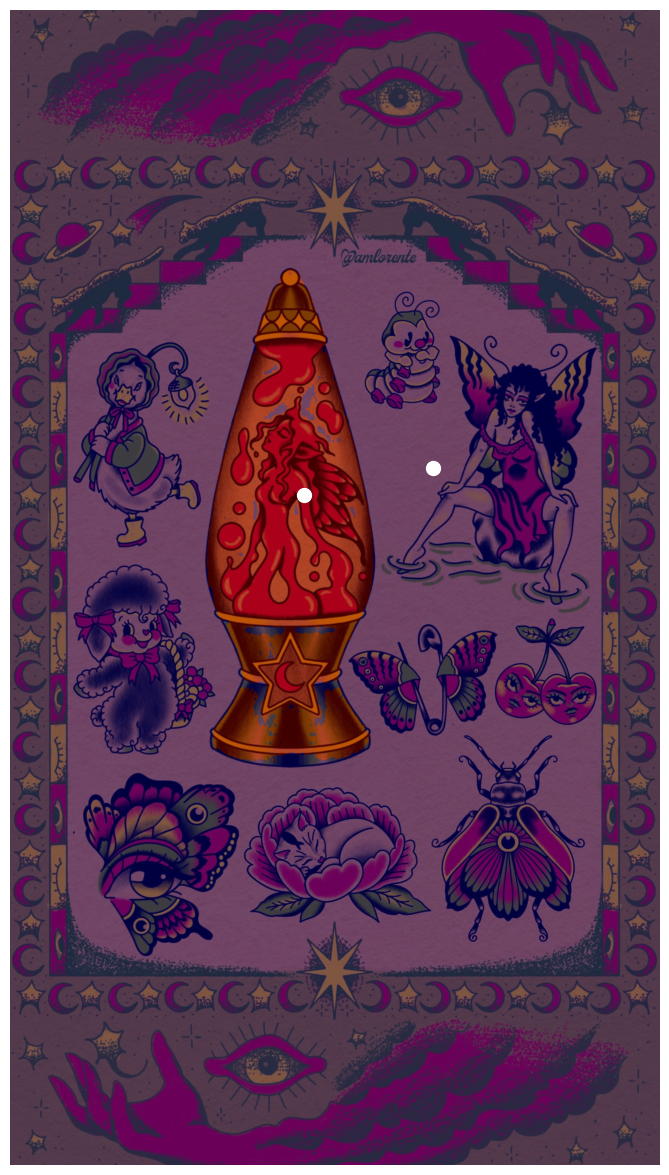

In [ ]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)
plt.figure(figsize=(10, 15))

plt.imshow(image)

plt.imshow(
    best_mask,
    alpha=0.5,
    cmap="jet"
)

plt.scatter(
    input_point[:, 0],
    input_point[:, 1],
    c="white",
    s=100
)

plt.axis("off")
plt.show()

## bounding box

In [ ]:
input_box = np.array([
    365,
    465,
    655,
    1400
])

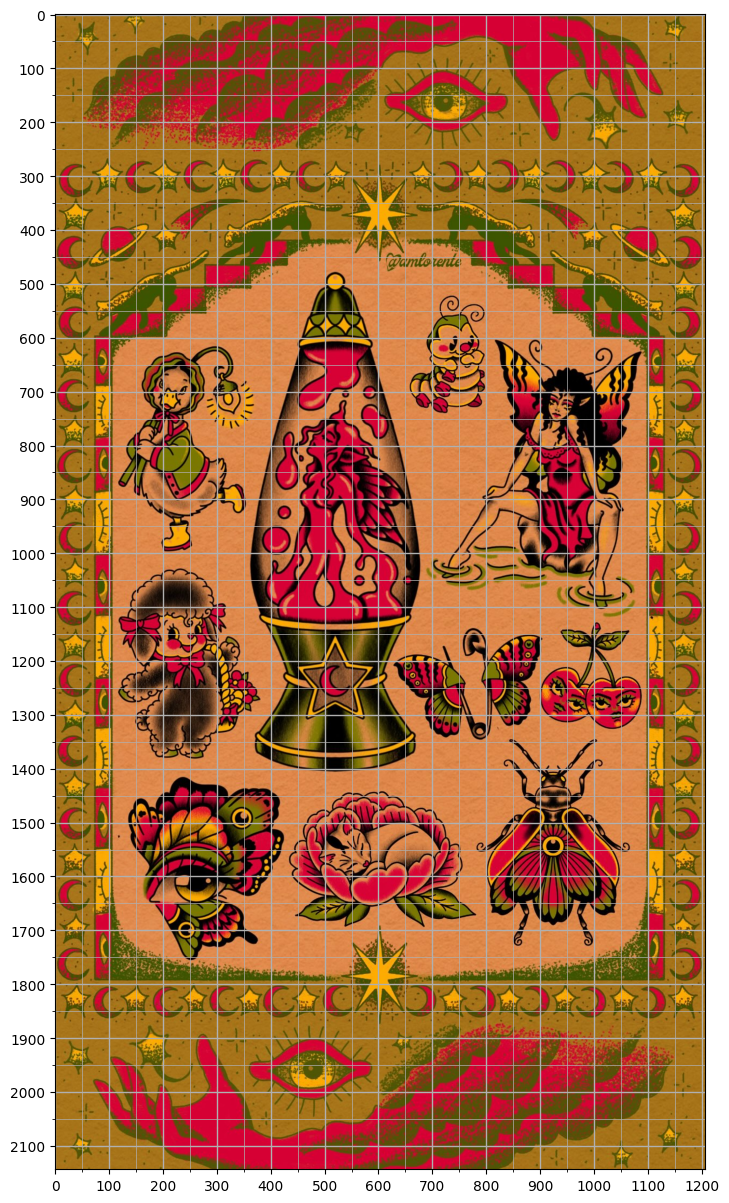

In [ ]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 15))

ax.imshow(image)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))

ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

ax.grid(which="major", linewidth=1)
ax.grid(which="minor", linewidth=0.5)

plt.show()

In [ ]:
masks, scores, logits = predictor.predict(
    box=input_box,
    multimask_output=True
)

In [ ]:
best_mask = masks[np.argmax(scores)]

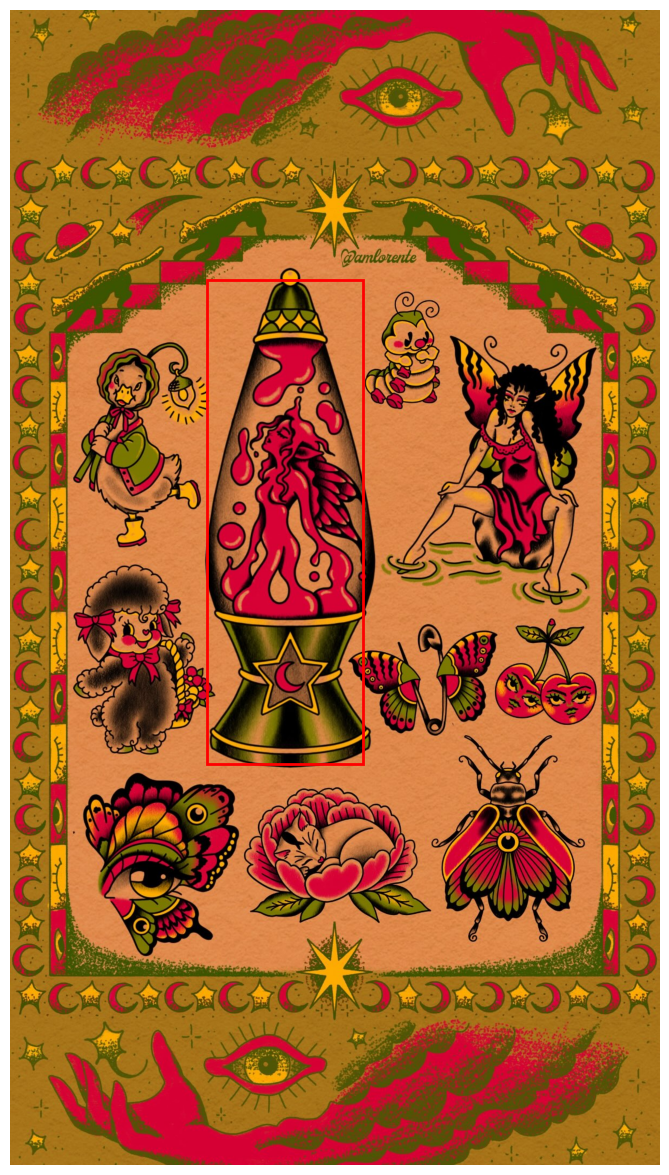

In [ ]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 15))

ax.imshow(image)

x1, y1, x2, y2 = input_box

rect = patches.Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)

ax.add_patch(rect)

plt.axis("off")
plt.show()

In [ ]:
rgba = np.zeros(
    (image.shape[0], image.shape[1], 4),
    dtype=np.uint8
)

In [ ]:
rgba[:, :, :3] = image

In [ ]:
rgba[:, :, 3] = best_mask.astype(np.uint8) * 255

In [ ]:
ys, xs = np.where(best_mask)

In [ ]:
x_min = xs.min()
x_max = xs.max()

y_min = ys.min()
y_max = ys.max()

In [ ]:
print(
    x_min,
    y_min,
    x_max,
    y_max
)

364 603 675 1406


In [ ]:
padding = 20

In [ ]:
x_min = max(0, x_min - padding)
y_min = max(0, y_min - padding)

x_max = min(image.shape[1], x_max + padding)
y_max = min(image.shape[0], y_max + padding)

In [ ]:
crop = rgba[
    y_min:y_max,
    x_min:x_max
]

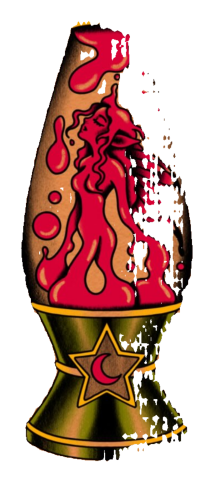

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(crop)
plt.axis("off")
plt.show()

## Salvar PNG

In [ ]:
output = Image.fromarray(crop)

output.save("recorte.png")

from google.colab import files

files.download("recorte.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>